# JAX ViT and Mixer and OpenVINO

[JAX](https://jax.readthedocs.io/en/latest) is a Python library for accelerator-oriented array computation and program transformation, designed for high-performance numerical computing and large-scale machine learning.
JAX provides a familiar NumPy-style API for ease of adoption by researchers and engineers.


In this tutorial we will show how to convert JAX [ViT](https://github.com/google-research/vision_transformer?tab=readme-ov-file#available-vit-models) and [Mixer](https://github.com/google-research/vision_transformer?tab=readme-ov-file#mlp-mixer) models in OpenVINO format.


### Vision Transformer
<img src="https://github.com/google-research/vision_transformer/blob/main/vit_figure.png?raw=true" width="800"> 
Overview of the model: authors split an image is splited into fixed-size patches, linearly embed each of them, add position embeddings, and feed the resulting sequence of vectors to a standard Transformer encoder. In order to perform classification, authors use the standard approach of adding an extra learnable "classification token" to the sequence.

### MLP-Mixer
<img src="https://github.com/google-research/vision_transformer/blob/main/mixer_figure.png?raw=true" width="800"> 
MLP-Mixer (Mixer for short) consists of per-patch linear embeddings, Mixer layers, and a classifier head. Mixer layers contain one token-mixing MLP and one channel-mixing MLP, each consisting of two fully-connected layers and a GELU nonlinearity. Other components include: skip-connections, dropout, and linear classifier head.


#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Load and run the original model and a sample](#Load-and-run-the-original-model-and-a-sample)
- [Convert the model to OpenVINO IR](#Convert-the-model-to-OpenVINO-IR)
- [Compiling models](#Compiling-models)
- [Run OpenVINO model inference](#Run-OpenVINO-model-inference)

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/jax-vit-mixer/jax-vit-mixer.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
from cmd_helper import clone_repo


clone_repo("https://github.com/google-research/vision_transformer.git")

PosixPath('vision_transformer')

In [ ]:
%pip install -q -U --pre "openvino>2024.4.0" --extra-index-url https://storage.openvinotoolkit.org/simple/wheels/nightly
%pip install -q Pillow "jax>=0.4.2" "absl-py>=0.12.0" "flax>=0.6.4" "pandas>=1.1.0" "tensorflow-cpu>=2.4.0" tqdm "einops>=0.3.0" "ml-collections>=0.1.0" gsutil

In [3]:
import PIL
import jax
import numpy as np
import os
import sys

from vit_jax import checkpoint
from vit_jax import models_vit
from vit_jax import models_mixer
from vit_jax.configs import models as models_config

import openvino as ov

In [4]:
import ipywidgets as widgets

available_models = ["ViT-B_32", "Mixer-B_16"]


model_to_use = widgets.Select(
    options=available_models,
    value=available_models[0],
    description="Select model:",
    disabled=False,
)

model_to_use

Select(description='Select model:', options=('ViT-B_32', 'Mixer-B_16'), value='ViT-B_32')

## Load and run the original model and a sample
[back to top ⬆️](#Table-of-contents:)

Download a pre-trained model.

In [5]:
model_name = model_to_use.value
model_config = models_config.MODEL_CONFIGS[model_name]


if model_name.startswith('Mixer'):
  # Download model trained on imagenet2012
  ![ -e "$model_name"_imagenet2012.npz ] || gsutil cp gs://mixer_models/imagenet1k/"$model_name".npz "$model_name"_imagenet2012.npz
  model = models_mixer.MlpMixer(num_classes=1000, **model_config)
else:
  # Download model pre-trained on imagenet21k and fine-tuned on imagenet2012.
  ![ -e "$model_name"_imagenet2012.npz ] || gsutil cp gs://vit_models/imagenet21k+imagenet2012/"$model_name".npz "$model_name"_imagenet2012.npz
  model = models_vit.VisionTransformer(num_classes=1000, **model_config)

Load and convert pretrained checkpoint.

In [6]:
params = checkpoint.load(f'{model_name}_imagenet2012.npz')
params['pre_logits'] = {}  # Need to restore empty leaf for Flax.

Get imagenet labels.

In [ ]:
!wget https://storage.googleapis.com/bit_models/ilsvrc2012_wordnet_lemmas.txt
imagenet_labels = dict(enumerate(open('ilsvrc2012_wordnet_lemmas.txt')))

Get a random picture with the correct dimensions.

In [ ]:
resolution = 224 if model_name.startswith('Mixer') else 384
!wget https://picsum.photos/$resolution -O picsum.jpg
img = PIL.Image.open('picsum.jpg')

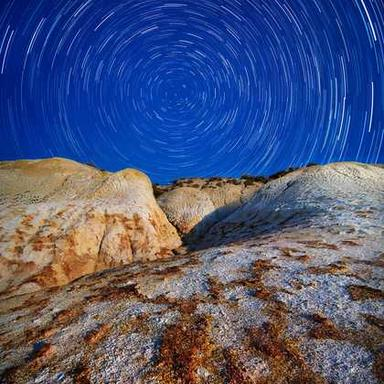

In [15]:
img

### Run the original model inference

In [9]:
# Predict on a batch with a single item (note very efficient TPU usage...)
data = (np.array(img) / 128 - 1)[None, ...]
logits, = model.apply(dict(params=params), data, train=False)

preds = np.array(jax.nn.softmax(logits))
for idx in preds.argsort()[:-11:-1]:
    print(f'{preds[idx]:.5f} : {imagenet_labels[idx]}', end='')

0.15862 : promontory, headland, head, foreland
0.10049 : beacon, lighthouse, beacon_light, pharos
0.07581 : volcano
0.06013 : seashore, coast, seacoast, sea-coast
0.03845 : valley, vale
0.03577 : cliff, drop, drop-off
0.03249 : coil, spiral, volute, whorl, helix
0.03002 : maze, labyrinth
0.02568 : lakeside, lakeshore
0.01380 : chambered_nautilus, pearly_nautilus, nautilus


## Convert the model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

OpenVINO supports JAX models via conversion to OpenVINO Intermediate Representation (IR). [OpenVINO model conversion API](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html#convert-a-model-with-python-convert-model) should be used for these purposes. `ov.convert_model` function accepts original PyTorch model instance and example input for tracing and returns `ov.Model` representing this model in OpenVINO framework. Converted model can be used for saving on disk using `ov.save_model` function or directly loading on device using `core.complie_model`.

In [10]:
from pathlib import Path


def convert(model: jax._src.core.ClosedJaxpr, xml_path: str):
    xml_path = Path(xml_path)
    if not xml_path.exists():
        xml_path.parent.mkdir(parents=True, exist_ok=True)
        converted_model = ov.convert_model(model)
        ov.save_model(converted_model, xml_path)

In [11]:
model_path = f"models/{model_name}.xml"

# HINT to wrap a model for conversion
# Later, this logic will be inside convert_model
def model_apply(x):
    return model.apply(dict(params=params), x, train=False)

# Create the ``jax._src.core.ClosedJaxpr`` object by using the ``jax.make_jaxpr`` function that can be converted into OpenVINO format.
jaxpr = jax.make_jaxpr(lambda x: model_apply(x))((np.array(img) / 128 - 1)[None, ...])

convert(jaxpr, model_path)

## Compiling models
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO.

In [12]:
from notebook_utils import device_widget


core = ov.Core()

device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [13]:
compiled_model = core.compile_model(model_path, device.value)

## Run OpenVINO model inference

In [14]:
logits_ov, = list(compiled_model(data).values())[0]

preds = np.array(jax.nn.softmax(logits_ov))
for idx in preds.argsort()[:-11:-1]:
    print(f'{preds[idx]:.5f} : {imagenet_labels[idx]}', end='')

0.15867 : promontory, headland, head, foreland
0.10057 : beacon, lighthouse, beacon_light, pharos
0.07568 : volcano
0.06010 : seashore, coast, seacoast, sea-coast
0.03839 : valley, vale
0.03573 : cliff, drop, drop-off
0.03254 : coil, spiral, volute, whorl, helix
0.03010 : maze, labyrinth
0.02567 : lakeside, lakeshore
0.01382 : chambered_nautilus, pearly_nautilus, nautilus
